# Quick model fits on `oyExt_all.csv` and PSE-vs-conflict comparison

Fits three candidate models to the single participant `oy` (with extended ±0.45 conflicts) and overlays each model's predicted PSE-vs-conflict on top of the empirical PSEs.

**Models** (matching the three-model BMS table):
1. `lognorm`               — causal-inference averaging (log-space)
2. `fusionOnlyLogNorm`     — forced fusion (no CI)
3. `switchingFree`         — probabilistic cue switching with free p_switch per audNoise

Optimised with `scipy.optimize.minimize` via the existing `fitCausalInferenceMonteCarlo` pipeline.

Speed settings used here: `nStart = 1`, `nSimul = 500` during fits; `nSimul = 2000` for the prediction curves. Bump both up if you want tighter results.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import norm

import loadData
import monteCarloClass

FONT_SIZE_LABEL = 18
FONT_SIZE_TITLE = 20
FONT_SIZE_LEGEND = 16
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': FONT_SIZE_LABEL,
    'axes.titlesize': FONT_SIZE_TITLE,
    'axes.labelsize': FONT_SIZE_LABEL,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
STANDARD_S  = 0.5
STANDARD_MS = 500

## 1. Load data + snap conflicts to canonical values

In [16]:
data, dataName = loadData.loadData('oyExt_all.csv', verbose=False)

CANONICAL_CONFLICTS_S = np.array([-0.45, -0.25, -0.17, -0.08, 0.0, 0.08, 0.17, 0.25, 0.45])

def snap_conflict(c, canonical=CANONICAL_CONFLICTS_S):
    return float(canonical[int(np.argmin(np.abs(canonical - c)))])

data['conflictDur'] = data['conflictDur'].apply(snap_conflict)
print('conflicts (ms):', sorted({int(round(c * 1000)) for c in data['conflictDur'].unique()}))
print('audNoise:', sorted(data['audNoise'].unique()))
print('N trials:', len(data))

conflicts (ms): [-450, -250, -170, -80, 0, 80, 170, 250, 450]
audNoise: [np.float64(0.1), np.float64(1.2)]
N trials: 2778


## 2. Fit the three models

`OmerMonteCarlo.fitCausalInferenceMonteCarlo` internally builds the binomial NLL over choice data and minimises with `scipy.minimize`. We use `sharedLambda=True` and `freeP_c=False` to keep the parameter count comparable across models.

In [17]:
MODELS = ['lognorm', 'fusionOnlyLogNorm', 'switchingFree']
DISPLAY = {
    'lognorm':           'CI averaging',
    'fusionOnlyLogNorm': 'Forced fusion',
    'switchingFree':     'Cue switching',
}
COLORS = {
    'lognorm':           '#1f77b4',
    'fusionOnlyLogNorm': '#7f7f7f',
    'switchingFree':     '#d62728',
}

from pathlib import Path
import json

MODEL_FITS_DIR = Path('model_fits_extendedConflict')


def make_model_runner(model_name, n_simul=500, n_start=1):
    mc = monteCarloClass.OmerMonteCarlo(data)
    mc.modelName        = model_name
    mc.sharedLambda     = True
    mc.freeP_c          = False
    mc.nSimul           = n_simul
    mc.nStart           = n_start
    mc.optimizationMethod = 'scipy'  # bads not installed
    return mc


def model_type_for(mc):
    model_type = mc.modelName
    model_type += '_LapseFix' if mc.sharedLambda else '_LapseFree'
    model_type += '_contextualPrior' if mc.freeP_c else '_sharedPrior'
    return model_type


def fit_path_for(mc):
    participant_id = dataName.split('_')[0]
    return MODEL_FITS_DIR / participant_id / f'{participant_id}_{model_type_for(mc)}_fit.json'


def ask_yes_no(prompt):
    while True:
        answer = input(prompt).strip().lower()
        if answer in {'yes', 'y'}:
            return True
        if answer in {'no', 'n', ''}:
            return False
        print('Please type yes or no.')


def fit_one_model(model_name, n_simul=500, n_start=1):
    mc = make_model_runner(model_name, n_simul=n_simul, n_start=n_start)
    t0 = time.time()
    fitted = mc.fitCausalInferenceMonteCarlo(mc.groupedData)
    dt = time.time() - t0
    nll = mc.nLLMonteCarloCausal(fitted, mc.groupedData)
    print(f'  {model_name}: fit in {dt:.1f}s, NLL={nll:.2f}, params={np.round(fitted, 3).tolist()}')
    return mc, fitted, nll


def load_existing_fit(model_name, n_simul=500, n_start=1):
    mc = make_model_runner(model_name, n_simul=n_simul, n_start=n_start)
    path = fit_path_for(mc)
    with open(path) as f:
        payload = json.load(f)
    params = np.array(payload['fittedParams'], dtype=float)
    nll = float(payload.get('NLL', -payload['logLikelihood']))
    n_params = int(payload.get('n_params', len(params)))
    aic = float(payload.get('AIC', 2 * n_params + 2 * nll))
    bic = float(payload.get('BIC', np.log(len(data)) * n_params + 2 * nll))
    print(f'  loaded existing {model_name}: NLL={nll:.2f}, params={np.round(params, 3).tolist()}')
    return dict(mc=mc, params=params, nll=nll,
                n_params=n_params, aic=aic, bic=bic)


fits = {}
for m in MODELS:
    print(f'\n=== {m} ===')
    mc_check = make_model_runner(m)
    existing_path = fit_path_for(mc_check)
    should_fit = True
    if existing_path.exists():
        should_fit = ask_yes_no(
            f'Existing fit found at {existing_path}. Continue fitting {m}? yes/no [no]: '
        )
    if should_fit:
        mc_obj, params, nll = fit_one_model(m)
        fits[m] = dict(mc=mc_obj, params=params, nll=nll,
                       n_params=len(params),
                       aic=2 * len(params) + 2 * nll,
                       bic=np.log(len(data)) * len(params) + 2 * nll)
    else:
        fits[m] = load_existing_fit(m)

summary = pd.DataFrame({
    'model':   [DISPLAY[m] for m in fits],
    'n_params': [fits[m]['n_params'] for m in fits],
    'NLL':     [fits[m]['nll'] for m in fits],
    'AIC':     [fits[m]['aic'] for m in fits],
    'BIC':     [fits[m]['bic'] for m in fits],
})
summary['ΔAIC'] = summary['AIC'] - summary['AIC'].min()
summary['ΔBIC'] = summary['BIC'] - summary['BIC'].min()
print('\n=== Summary ===')
print(summary.round(2).to_string(index=False))


=== lognorm ===
  loaded existing lognorm: NLL=1485.38, params=[0.103, 0.291, 0.716, 0.893, 0.439]

=== fusionOnlyLogNorm ===
  loaded existing fusionOnlyLogNorm: NLL=1485.00, params=[0.146, 0.253, 0.954, 0.372]

=== switchingFree ===
  loaded existing switchingFree: NLL=1473.91, params=[0.085, 0.256, 1.029, 0.044, 0.127, 0.366]

=== Summary ===
        model  n_params     NLL     AIC     BIC  ΔAIC  ΔBIC
 CI averaging         5 1485.38 2980.76 3010.41 20.94 15.01
Forced fusion         4 1485.00 2978.01 3001.73 18.19  6.33
Cue switching         6 1473.91 2959.82 2995.40  0.00  0.00


## 2b. Save currently loaded model fits

Run this cell after the fits are already in memory. It only serializes the existing `fits` object; it does not refit the models.

In [18]:
from pathlib import Path
import json

if 'fits' not in globals() or not fits:
    raise RuntimeError('No fits object found in this notebook kernel. Run this only in the kernel where the models are already fitted.')

MODEL_FITS_DIR = Path('model_fits_extendedConflict')
PARTICIPANT_ID = dataName.split('_')[0]
participant_dir = MODEL_FITS_DIR / PARTICIPANT_ID
participant_dir.mkdir(parents=True, exist_ok=True)

models_to_save = [m for m in MODELS if m in fits]

summary_to_save = pd.DataFrame({
    'model': [DISPLAY.get(m, m) for m in models_to_save],
    'n_params': [fits[m]['n_params'] for m in models_to_save],
    'NLL': [fits[m]['nll'] for m in models_to_save],
    'AIC': [fits[m]['aic'] for m in models_to_save],
    'BIC': [fits[m]['bic'] for m in models_to_save],
})
summary_to_save['ΔAIC'] = summary_to_save['AIC'] - summary_to_save['AIC'].min()
summary_to_save['ΔBIC'] = summary_to_save['BIC'] - summary_to_save['BIC'].min()

def _jsonable_params(params):
    return params.tolist() if hasattr(params, 'tolist') else list(params)

saved_fit_paths = []
for m in models_to_save:
    mc = fits[m]['mc']
    params = fits[m]['params']

    model_type = m
    model_type += '_LapseFix' if mc.sharedLambda else '_LapseFree'
    model_type += '_contextualPrior' if mc.freeP_c else '_sharedPrior'

    out_path = participant_dir / f'{PARTICIPANT_ID}_{model_type}_fit.json'
    payload = {
        'participantID': PARTICIPANT_ID,
        'dataName': dataName,
        'modelName': m,
        'modelType': model_type,
        'extendedConflict': True,
        'conflictDurationsS': sorted(float(c) for c in data['conflictDur'].unique()),
        'audNoiseLevels': sorted(float(a) for a in data['audNoise'].unique()),
        'sharedLambda': bool(mc.sharedLambda),
        'freeP_c': bool(mc.freeP_c),
        'nSimul': int(mc.nSimul),
        'nStart': int(mc.nStart),
        'optimizationMethod': mc.optimizationMethod,
        'fittedParams': _jsonable_params(params),
        'NLL': float(fits[m]['nll']),
        'AIC': float(fits[m]['aic']),
        'BIC': float(fits[m]['bic']),
        'logLikelihood': float(-fits[m]['nll']),
        'n_params': int(fits[m]['n_params']),
        'n_trials': int(len(data)),
        'n_conditions': int(len(mc.groupedData)),
    }
    with open(out_path, 'w') as f:
        json.dump(payload, f, indent=4)
    saved_fit_paths.append(out_path)

summary_path = participant_dir / f'{PARTICIPANT_ID}_model_summary.csv'
summary_to_save.to_csv(summary_path, index=False)

print(f'Saved {len(saved_fit_paths)} model fits to {participant_dir}')
for path in saved_fit_paths:
    print(f'  {path}')
print(f'  {summary_path}')

Saved 3 model fits to model_fits_extendedConflict/oyExt
  model_fits_extendedConflict/oyExt/oyExt_lognorm_LapseFix_sharedPrior_fit.json
  model_fits_extendedConflict/oyExt/oyExt_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json
  model_fits_extendedConflict/oyExt/oyExt_switchingFree_LapseFix_sharedPrior_fit.json
  model_fits_extendedConflict/oyExt/oyExt_model_summary.csv


## 3. Helpers — empirical PSE and model-predicted PSE per condition

Custom binomial / cross-entropy NLL + `scipy.minimize` (no `curve_fit`). The secondary psychometric is log-normal: a cumulative Gaussian over `log(testDurS / standardDur)`.

In [28]:
def lognormal_pf_from_ratio(log_ratio, mu, sigma, lam):
    return lam / 2.0 + (1.0 - lam) * norm.cdf((log_ratio - mu) / sigma)


def log_mu_to_shift_s(mu, standard_s=STANDARD_S):
    return standard_s * (np.exp(mu) - 1.0)


def log_sigma_to_width_s(sigma, standard_s=STANDARD_S):
    return standard_s * (np.exp(sigma) - 1.0)

BOUNDS = [(-0.6, 0.6), (1e-3, 1.5), (0.0, 0.4)]
INITS = [[0.0, 0.10, 0.02], [0.0, 0.05, 0.02], [0.05, 0.20, 0.05], [-0.05, 0.30, 0.02]]


def _binom_nll(params, log_ratios, n_chose, n_total):
    mu, sigma, lam = params
    if sigma <= 0 or lam < 0 or lam > 0.4:
        return 1e10
    p = np.clip(lognormal_pf_from_ratio(log_ratios, mu, sigma, lam), 1e-9, 1 - 1e-9)
    return -float(np.sum(n_chose * np.log(p) + (n_total - n_chose) * np.log(1 - p)))


def _xent_nll(params, log_ratios, p_target):
    mu, sigma, lam = params
    if sigma <= 0 or lam < 0 or lam > 0.4:
        return 1e10
    p = np.clip(lognormal_pf_from_ratio(log_ratios, mu, sigma, lam), 1e-9, 1 - 1e-9)
    return -float(np.sum(p_target * np.log(p) + (1 - p_target) * np.log(1 - p)))


def fit_pf(nll_fn, args):
    best = None
    for x0 in INITS:
        try:
            res = minimize(nll_fn, x0, args=args, bounds=BOUNDS, method='L-BFGS-B')
            if res.success and (best is None or res.fun < best.fun):
                best = res
        except Exception:
            continue
    return best.x if best is not None else np.array([np.nan]*3)


# --- empirical PSE per condition (log-normal binomial NLL on real choices) ---
def empirical_pse(mc, audNoise):
    g = mc.groupedData
    sub = g[np.isclose(g['audNoise'], audNoise)]
    rows = []
    for c in sorted(sub['conflictDur'].unique()):
        s = sub[np.isclose(sub['conflictDur'], c)]
        if len(s) < 3:
            continue
        log_ratios = np.log(s['testDurS'].values / s['standardDur'].values)
        mu, sigma, lam = fit_pf(_binom_nll,
                                (log_ratios,
                                 s['num_of_chose_test'].values.astype(float),
                                 s['total_responses'].values.astype(float)))
        rows.append(dict(conflict=float(c), mu=mu, sigma=sigma, lam=lam,
                         N=int(s['total_responses'].sum())))
    return pd.DataFrame(rows)


# --- model-predicted PSE per condition (forward sim -> log-normal PF fit) ---
DELTAS_PRED = np.linspace(-0.40, 0.40, 25)


def model_predicted_pse(mc, fitted, audNoise, n_simul=2000):
    mc.nSimul = n_simul
    g = mc.groupedData
    conflicts = sorted({float(c) for c in g[np.isclose(g['audNoise'], audNoise)]['conflictDur'].unique()})
    rows = []
    for c in conflicts:
        params_res = mc.getParamsCausal(fitted, audNoise, c)
        if mc.modelName == 'switchingWithConflict':
            lam, sa, sv, pc, k, tmin, tmax = params_res
        elif mc.modelName == 'switchingFree':
            lam, sa, sv, p_sw, tmin, tmax = params_res
            pc = p_sw  # passes as p_c into probTestLonger
        else:
            lam, sa, sv, pc, tmin, tmax = params_res
        p_long = np.empty_like(DELTAS_PRED)
        for i, d in enumerate(DELTAS_PRED):
            S_a_s = STANDARD_S; S_v_s = S_a_s + c
            S_a_t = S_a_s + d; S_v_t = S_a_t
            p_long[i] = mc.probTestLonger_vectorized_mc(
                (S_a_s, S_a_t, S_v_s, S_v_t), sa, sv, pc, lam, tmin, tmax)
        test_durs = STANDARD_S + DELTAS_PRED
        log_ratios = np.log(test_durs / STANDARD_S)
        mu, sigma, _ = fit_pf(_xent_nll, (log_ratios, p_long))
        rows.append(dict(conflict=c, mu=mu, sigma=sigma))
    return pd.DataFrame(rows)

## 4. Extract empirical and predicted PSEs

In [29]:
noise_levels = sorted(data['audNoise'].unique())
noise_labels = {noise_levels[0]: 'Low auditory noise',
                noise_levels[1]: 'High auditory noise'}

emp_by_noise = {}
pred_by_model_noise = {m: {} for m in MODELS}
for n in noise_levels:
    emp_by_noise[n] = empirical_pse(fits[MODELS[0]]['mc'], n)
    for m in MODELS:
        pred_by_model_noise[m][n] = model_predicted_pse(fits[m]['mc'], fits[m]['params'], n)
    print(f'\n--- audNoise = {n} ---')
    print('empirical:')
    print(emp_by_noise[n][['conflict', 'mu', 'sigma', 'lam', 'N']].round(3).to_string(index=False))
    for m in MODELS:
        print(f'predicted ({DISPLAY[m]}):')
        print(pred_by_model_noise[m][n][['conflict', 'mu', 'sigma']].round(3).to_string(index=False))


--- audNoise = 0.1 ---
empirical:
 conflict     mu  sigma   lam   N
    -0.45 -0.013  0.389 0.000 165
    -0.25  0.125  0.029 0.400 135
    -0.17  0.003  0.247 0.090 142
    -0.08  0.037  0.487 0.000 183
     0.00 -0.036  0.471 0.000 172
     0.08  0.080  0.533 0.000 151
     0.17 -0.060  0.500 0.000 155
     0.25  0.037  0.545 0.000 147
     0.45 -0.056  0.388 0.043 135
predicted (CI averaging):
 conflict     mu  sigma
    -0.45 -0.106  0.426
    -0.25 -0.078  0.382
    -0.17 -0.051  0.380
    -0.08 -0.020  0.378
     0.00  0.001  0.379
     0.08  0.018  0.382
     0.17  0.037  0.379
     0.25  0.058  0.376
     0.45  0.088  0.380
predicted (Forced fusion):
 conflict     mu  sigma
    -0.45 -0.153  0.353
    -0.25 -0.042  0.344
    -0.17 -0.026  0.338
    -0.08 -0.012  0.348
     0.00 -0.000  0.348
     0.08  0.011  0.344
     0.17  0.019  0.346
     0.25  0.026  0.349
     0.45  0.041  0.344
predicted (Cue switching):
 conflict     mu  sigma
    -0.45 -0.028  0.355
    -0.25 -0.017 

## 4b. Trial-bootstrap 95% CI on the empirical PSEs

Within each (audNoise, conflict) cell, resample trials with replacement (`N_BOOT` reps), refit a log-normal PF, store log-space μ and σ. Percentile 95% CIs are used as empirical error bars in the next plots.

Default `N_BOOT = 1000` — drop to 200 for a quick sanity check, raise above 1000 for tighter intervals.

In [30]:
N_BOOT = 1000
_rng = np.random.default_rng(0)


def _fit_pf_fast(log_ratios, n_chose, n_total):
    # Single-start variant for the bootstrap inner loop (cheaper).
    try:
        res = minimize(_binom_nll, [0.0, 0.10, 0.02],
                       args=(log_ratios, n_chose, n_total),
                       bounds=BOUNDS, method='L-BFGS-B')
        if res.success:
            return res.x
    except Exception:
        pass
    return np.array([np.nan, np.nan, np.nan])


def bootstrap_empirical_pse(audNoise, n_boot=N_BOOT):
    sub = data[np.isclose(data['audNoise'], audNoise)]
    rows = []
    for c in sorted(sub['conflictDur'].unique()):
        cell = sub[np.isclose(sub['conflictDur'], c)]
        log_ratio_all = np.log(cell['testDurS'].values.astype(float) /
                               cell['standardDur'].values.astype(float))
        y_all = cell['chose_test'].values.astype(float)
        n = len(cell)
        if n < 10:
            continue
        mus = np.full(n_boot, np.nan)
        sigmas = np.full(n_boot, np.nan)
        for b in range(n_boot):
            idx = _rng.integers(0, n, size=n)
            log_b, y_b = log_ratio_all[idx], y_all[idx]
            uniq, inv = np.unique(log_b, return_inverse=True)
            if len(uniq) < 3:
                continue
            n_total = np.bincount(inv).astype(float)
            n_chose = np.bincount(inv, weights=y_b).astype(float)
            mu, sigma, _ = _fit_pf_fast(uniq, n_chose, n_total)
            mus[b] = mu
            sigmas[b] = sigma
        rows.append(dict(
            conflict=float(c),
            mu_lo=float(np.nanpercentile(mus, 2.5)),
            mu_hi=float(np.nanpercentile(mus, 97.5)),
            mu_med=float(np.nanmedian(mus)),
            sigma_lo=float(np.nanpercentile(sigmas, 2.5)),
            sigma_hi=float(np.nanpercentile(sigmas, 97.5)),
            sigma_med=float(np.nanmedian(sigmas)),
            n=int(n),
        ))
    return pd.DataFrame(rows)


t0 = time.time()
boot_by_noise = {n: bootstrap_empirical_pse(n) for n in noise_levels}
print(f'bootstrap done in {time.time() - t0:.1f}s')
for n in noise_levels:
    print(f'\n--- audNoise = {n} ---')
    b = boot_by_noise[n].copy()
    b['conflict_ms']     = (b['conflict'] * 1000).round().astype(int)
    b['mu_med_ms']       = log_mu_to_shift_s(b['mu_med']) * 1000
    b['mu_lo_ms']        = log_mu_to_shift_s(b['mu_lo'])  * 1000
    b['mu_hi_ms']        = log_mu_to_shift_s(b['mu_hi'])  * 1000
    b['sigma_med_ms']    = log_sigma_to_width_s(b['sigma_med']) * 1000
    b['sigma_lo_ms']     = log_sigma_to_width_s(b['sigma_lo'])  * 1000
    b['sigma_hi_ms']     = log_sigma_to_width_s(b['sigma_hi'])  * 1000
    print(b[['conflict_ms', 'n', 'mu_med_ms', 'mu_lo_ms', 'mu_hi_ms',
             'sigma_med_ms', 'sigma_lo_ms', 'sigma_hi_ms']].round(1).to_string(index=False))

bootstrap done in 66.8s

--- audNoise = 0.1 ---
 conflict_ms   n  mu_med_ms  mu_lo_ms  mu_hi_ms  sigma_med_ms  sigma_lo_ms  sigma_hi_ms
        -450 165       -6.8     -47.5      39.3         234.5        171.0        339.3
        -250 135        6.8     -84.0      98.3         132.0          0.5        587.8
        -170 142        0.7     -51.7      56.2         136.8          0.5        228.3
         -80 183       17.2     -33.9      77.7         306.3        137.5        487.4
           0 172      -18.7     -72.5      40.7         295.6        199.3        456.2
          80 151       38.8     -21.0     116.3         342.8        201.3        597.8
         170 155      -27.7     -86.2      35.0         317.2        160.7        546.9
         250 147       21.5     -44.3      91.2         358.0        208.3        709.2
         450 135      -29.2     -78.2      33.8         218.1          0.5        421.0

--- audNoise = 1.2 ---
 conflict_ms   n  mu_med_ms  mu_lo_ms  mu_hi_ms 

## 5. Plot — data PSE vs conflict with each model overlaid

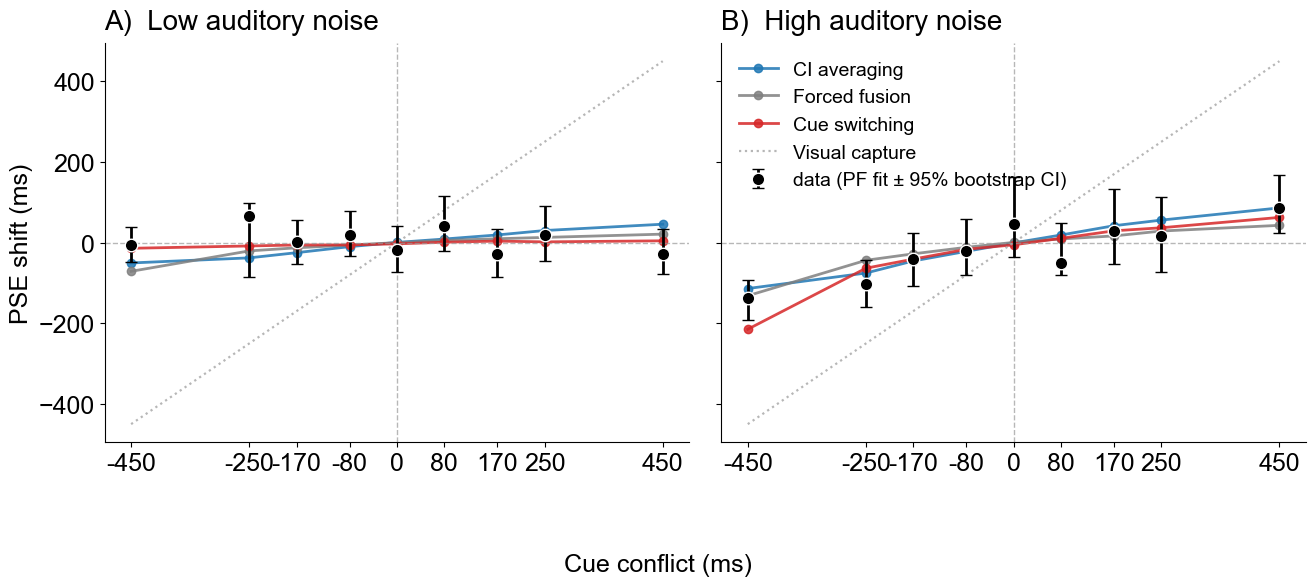

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), sharey=True)
panel_prefix = ['A)', 'B)']
for idx, n in enumerate(noise_levels):
    ax  = axes[idx]
    emp = emp_by_noise[n].sort_values('conflict')
    boot = boot_by_noise[n].sort_values('conflict')
    # Empirical points: point fit centre + bootstrap percentile CI as error bars.
    merged = emp.merge(boot[['conflict', 'mu_lo', 'mu_hi']], on='conflict', how='left')
    y     = log_mu_to_shift_s(merged['mu'].values) * 1000
    ylo   = log_mu_to_shift_s(merged['mu_lo'].values) * 1000
    yhi   = log_mu_to_shift_s(merged['mu_hi'].values) * 1000
    ax.errorbar(merged['conflict'].values * 1000, y,
                yerr=[np.maximum(0, y - ylo), np.maximum(0, yhi - y)],
                fmt='o', color='black', ms=9, lw=2, capsize=4, capthick=1.4,
                mfc='black', mec='white', mew=1.0,
                label='data (PF fit ± 95% bootstrap CI)', zorder=5)
    # Model prediction lines.
    for m in MODELS:
        pred = pred_by_model_noise[m][n].sort_values('conflict')
        ax.plot(pred['conflict'] * 1000, log_mu_to_shift_s(pred['mu']) * 1000,
                '-o', color=COLORS[m], lw=2, ms=6, alpha=0.85,
                label=DISPLAY[m])
    ax.axhline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    cf_ms = sorted(set(int(round(c * 1000)) for c in emp['conflict']))
    ax.plot(cf_ms, cf_ms, color='#aaaaaa', linestyle=':', linewidth=1.6, alpha=0.85,
            label='Visual capture' if idx == 1 else None)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[n]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(cf_ms)
    ax.set_xticklabels([str(t) for t in cf_ms], fontsize=FONT_SIZE_LABEL - 4)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    if idx == 1:
        ax.legend(fontsize=FONT_SIZE_LEGEND - 2, frameon=False, loc='upper left')
axes[0].set_ylabel('PSE shift (ms)', fontsize=FONT_SIZE_LABEL)
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig('oyExt_pse_models_vs_data.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_pse_models_vs_data.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Plot — model-predicted psychometric slope vs conflict

This uses the log-space `sigma` from the log-normal PF fit to each model's predicted psychometric curve, not the internal sensory-noise parameters of the causal models. Values are converted to an approximate ms width for display.

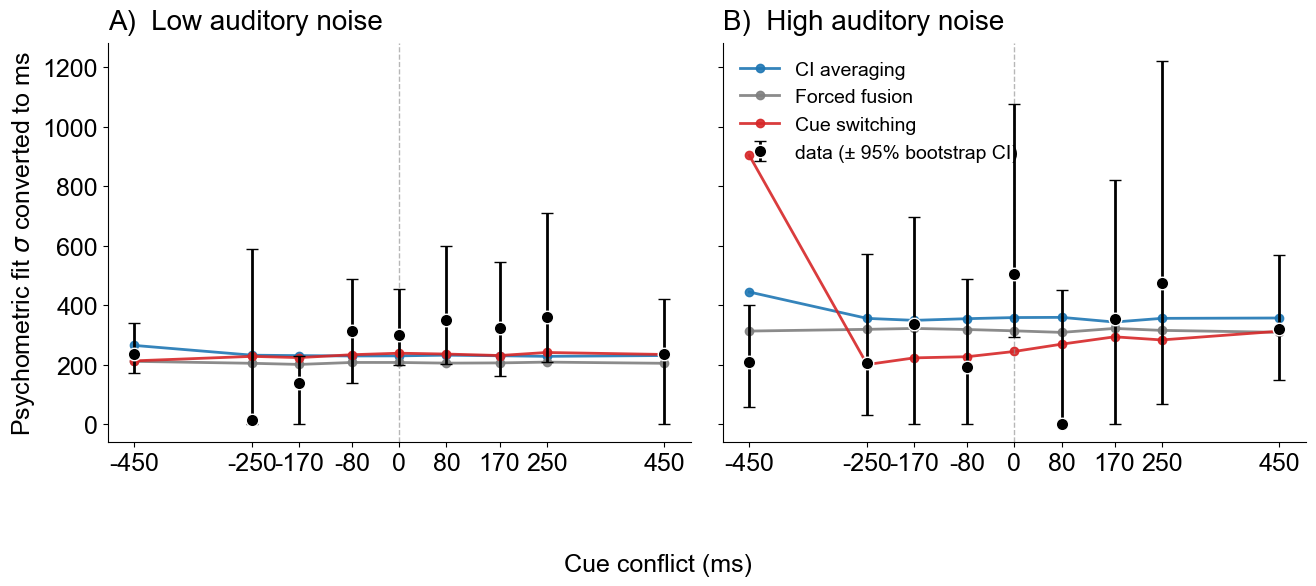

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), sharey=True)
panel_prefix = ['A)', 'B)']

for idx, n in enumerate(noise_levels):
    ax = axes[idx]

    emp = emp_by_noise[n].sort_values('conflict')
    boot = boot_by_noise[n].sort_values('conflict')
    merged = emp.merge(boot[['conflict', 'sigma_lo', 'sigma_hi']], on='conflict', how='left')
    y = log_sigma_to_width_s(merged['sigma'].values) * 1000
    ylo = log_sigma_to_width_s(merged['sigma_lo'].values) * 1000
    yhi = log_sigma_to_width_s(merged['sigma_hi'].values) * 1000
    ax.errorbar(merged['conflict'].values * 1000, y,
                yerr=[np.maximum(0, y - ylo), np.maximum(0, yhi - y)],
                fmt='o', color='black', ms=9, lw=2, capsize=4, capthick=1.4,
                mfc='black', mec='white', mew=1.0,
                label='data (± 95% bootstrap CI)', zorder=5)

    for m in MODELS:
        pred = pred_by_model_noise[m][n].sort_values('conflict')
        ax.plot(pred['conflict'] * 1000, log_sigma_to_width_s(pred['sigma']) * 1000,
                '-o', color=COLORS[m], lw=2, ms=6, alpha=0.9,
                label=DISPLAY[m])

    cf_ms = sorted(set(int(round(c * 1000))
                       for c in emp['conflict']).union(
                       int(round(c * 1000))
                       for m in MODELS
                       for c in pred_by_model_noise[m][n]['conflict']))
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[n]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(cf_ms)
    ax.set_xticklabels([str(t) for t in cf_ms], fontsize=FONT_SIZE_LABEL - 4)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    if idx == 1:
        ax.legend(fontsize=FONT_SIZE_LEGEND - 2, frameon=False, loc='upper left')

axes[0].set_ylabel('Psychometric fit $\\sigma$ converted to ms', fontsize=FONT_SIZE_LABEL)
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig('oyExt_sigma_models_vs_conflict.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_sigma_models_vs_conflict.png', dpi=300, bbox_inches='tight')
plt.show()

## Files produced

- `oyExt_pse_models_vs_data.{pdf,png}` — PSE-vs-conflict with empirical PSEs and three model predictions overlaid, both audio-noise levels.
- `oyExt_sigma_models_vs_conflict.{pdf,png}` — psychometric-fit sigma vs conflict for each model prediction, both audio-noise levels.

Model summary (NLL, AIC, BIC, ΔAIC, ΔBIC) printed inline in section 2. For a more rigorous comparison bump `n_start=3` and `n_simul=2000` in section 2 — current settings prioritise speed.